# Evaluation: Blind Recovery of Latent Domains

Load a trained model and analyse:
- The learned lifting map $L$
- The group generators $G$
- The lifted representation on test data
- Generator similarity $S_{0.75}$ against ground-truth finite-difference operator

## 1. Setup

In [1]:
import sys, os
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)

import json
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from core.train_utils import create_model, make_data_generator

print('TensorFlow:', tf.__version__)

2026-06-26 14:29:59.213495: I tensorflow/core/util/port.cc:111] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 14:29:59.244737: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-26 14:29:59.244765: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-26 14:29:59.244788: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-26 14:29:59.251457: I tensorflow/core/platform/cpu_feature_g

TensorFlow: 2.14.0


## 2. Select experiment to evaluate

Point to a directory under `experiments/` that contains `specs.json` and a saved weights file.

In [ ]:
EXP_NAME = 'HEADDIRECTION-EXP-0'  # change to your experiment
EPOCH    = None   # None -> pick the latest available checkpoint

exp_dir    = os.path.join(REPO_ROOT, 'experiments', EXP_NAME)
epochs_dir = os.path.join(exp_dir, 'epochs')
specs_path = os.path.join(exp_dir, 'specs.json')

with open(specs_path) as f:
    exp_specs = json.load(f)

# Find available checkpoints (numeric sort: ep300 > ep90)
h5_files = sorted(
    [f for f in os.listdir(epochs_dir) if f.endswith('.h5')],
    key=lambda f: int(f[2:-3])
)
print(f'Available checkpoints: {h5_files}')

if EPOCH is None:
    weights_path = os.path.join(epochs_dir, h5_files[-1])
else:
    weights_path = os.path.join(epochs_dir, f'ep{EPOCH}.h5')

print(f'Loading weights from: {weights_path}')

## 3. Rebuild model and load weights

In [3]:
seed = exp_specs.get('seed', 0)
np.random.seed(seed)
tf.random.set_seed(seed)

model = create_model(**exp_specs['model_params'])

# Build model by running a forward pass
dg_tmp = make_data_generator(seed=seed, **exp_specs['data_generator_params'])
sample = tf.constant(dg_tmp.sample_batch_of_data(), dtype=tf.float32)
_ = model(sample, training=False)

model.load_weights(weights_path)
print('Weights loaded.')
model.summary()

2026-06-26 14:30:04.285622: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20619 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:19:00.0, compute capability: 8.6
2026-06-26 14:30:04.286710: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 22282 MB memory:  -> device: 1, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:1a:00.0, compute capability: 8.6
2026-06-26 14:30:04.287632: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 22282 MB memory:  -> device: 2, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:67:00.0, compute capability: 8.6
2026-06-26 14:30:04.288548: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1886] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 22046 MB memory:  -> device: 3, name: NVIDIA GeForce RTX 3090

Loading th-1 session from: th1_data/Mouse12-120806...


/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/

   -> Reading head angle from th1_data/Mouse12-120806/Mouse12-120806.whl
   -> Reading wake epoch from th1_data/Mouse12-120806/Mouse12-120806.states.Wake
   -> Using 23 units from adn.
Generating head-direction dataset...
   -> Bin size: 0.025s | Smoothing std: 0.05s
   -> Produced 87556 samples of dimension 23.


2026-06-26 14:30:14.308055: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-26 14:30:16.124864: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8700
2026-06-26 14:30:16.667743: I tensorflow/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2026-06-26 14:30:18.524246: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x56358a2b6040


Weights loaded.
Model: "gsl_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 symmetry_preserving_batch_  multiple                  2         
 norm (SymmetryPreservingBa                                      
 tchNorm)                                                        
                                                                 
 lifting_layer (LiftingLaye  multiple                  15751     
 r)                                                              
                                                                 
 uniformity_estimator_0 (Un  multiple                  1472      
 iformityEstimator)                                              
                                                                 
 probability_estimator_0 (P  multiple                  360       
 robabilityEstimator)                                            
                                         

## 4. Generate test data

In [4]:
dg = make_data_generator(seed=seed + 999, **exp_specs['data_generator_params'])
dg.reset_batch_counter()
x_test = np.concatenate([dg.sample_batch_of_data() for _ in range(5)], axis=0)
print(f'Test data shape: {x_test.shape}')

Loading th-1 session from: th1_data/Mouse12-120806...


/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/site-packages/hdmf/utils.py:592: DeprecationWarning: The 'manufacturer' field is deprecated. Instead, use DeviceModel.manufacturer and link to that DeviceModel from this Device.
  return func(args[0], **pargs)
/home/ege/.local/lib/python3.10/

   -> Reading head angle from th1_data/Mouse12-120806/Mouse12-120806.whl
   -> Reading wake epoch from th1_data/Mouse12-120806/Mouse12-120806.states.Wake
   -> Using 23 units from adn.
Generating head-direction dataset...
   -> Bin size: 0.025s | Smoothing std: 0.05s
   -> Produced 87556 samples of dimension 23.
Test data shape: (12500, 20)


## 5. Lifting map

Lifting map L shape: (125, 30)
Lifted output shape: (64, 30, 1)


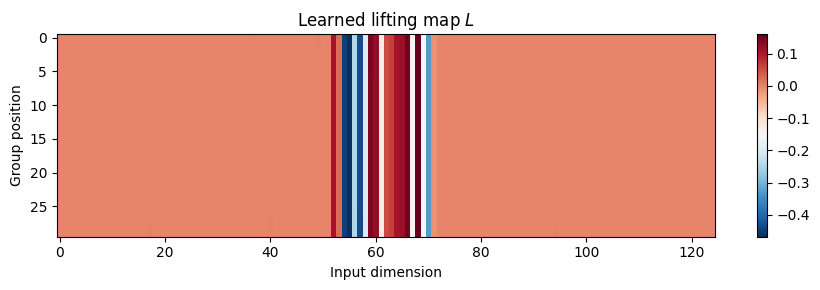

In [5]:
x_tf = tf.constant(x_test[:64], dtype=tf.float32)
lifted, L = model(x_tf, training=False, analyze=True)

L_np = L.numpy()   # shape: (input_dim, group_positions * channels)

print(f'Lifting map L shape: {L_np.shape}')
print(f'Lifted output shape: {lifted.shape}')

plt.figure(figsize=(9, 3))
plt.imshow(L_np.T, aspect='auto', cmap='RdBu_r')
plt.colorbar()
plt.xlabel('Input dimension')
plt.ylabel('Group position')
plt.title('Learned lifting map $L$')
plt.tight_layout(); plt.show()

## 6. Generator matrices

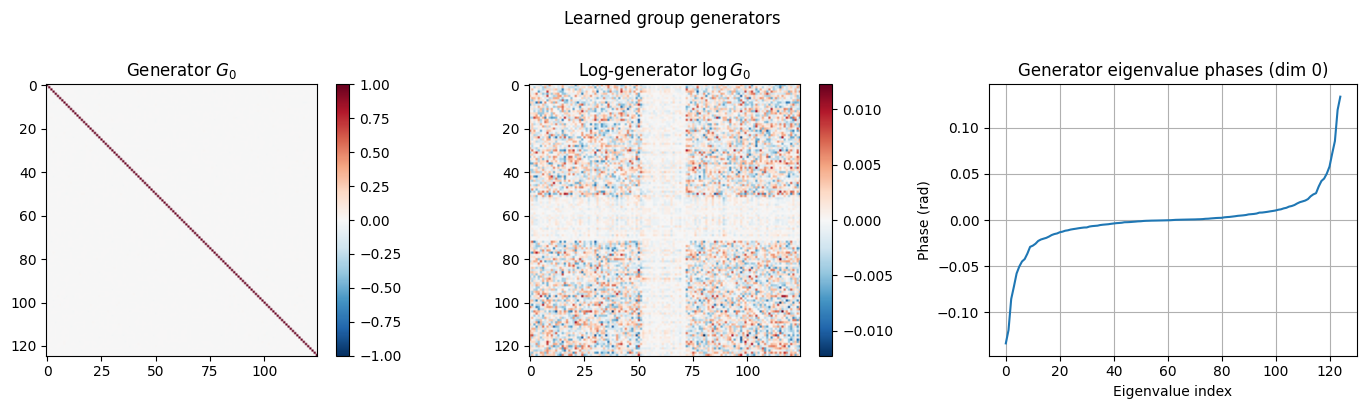

In [6]:
G     = model.lifting_layer.generators.numpy()      # (group_dims, D, D)
log_G = model.lifting_layer.log_generators.numpy()  # (group_dims, D, D)
phases = model.lifting_layer.generator_phases.numpy()  # (group_dims, D)

fig, axes = plt.subplots(G.shape[0], 3, figsize=(14, 4 * G.shape[0]))
if G.shape[0] == 1:
    axes = [axes]

for d, row in enumerate(axes):
    im0 = row[0].imshow(G[d], cmap='RdBu_r', vmin=-1, vmax=1)
    row[0].set_title(f'Generator $G_{d}$')
    plt.colorbar(im0, ax=row[0])

    im1 = row[1].imshow(log_G[d], cmap='RdBu_r')
    row[1].set_title(f'Log-generator $\\log G_{d}$')
    plt.colorbar(im1, ax=row[1])

    row[2].plot(np.sort(phases[d]))
    row[2].set_title(f'Generator eigenvalue phases (dim {d})')
    row[2].set_xlabel('Eigenvalue index'); row[2].set_ylabel('Phase (rad)')
    row[2].grid(True)

plt.suptitle('Learned group generators', y=1.01)
plt.tight_layout(); plt.show()

## 7. Lifted representation samples

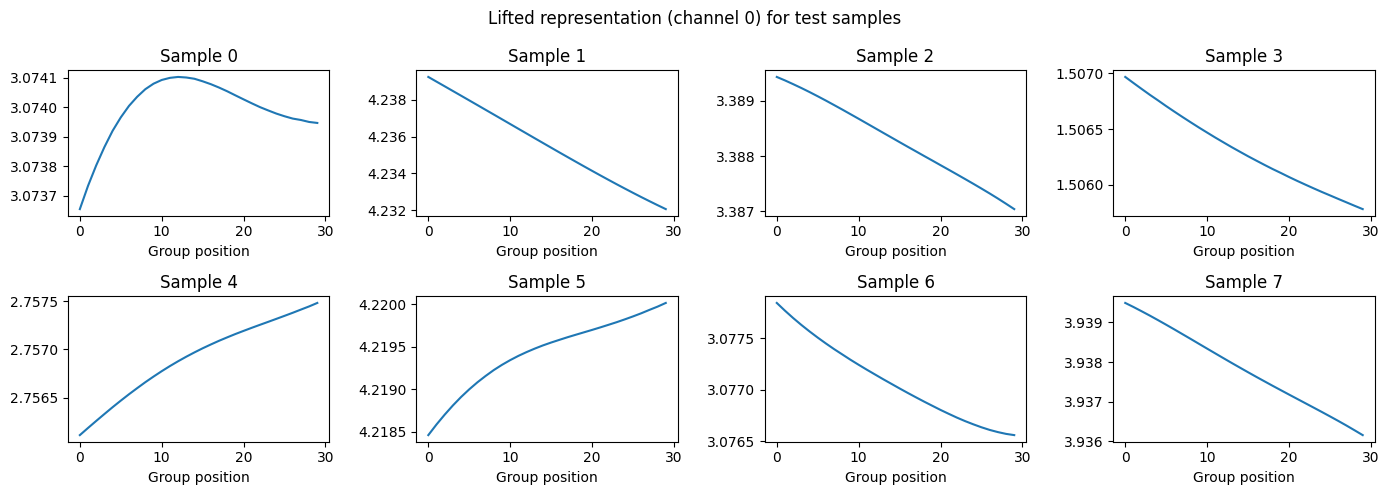

In [7]:
lifted_np = lifted.numpy()   # (batch, positions, channels)
n_show = min(8, lifted_np.shape[0])

fig, axes = plt.subplots(2, n_show // 2, figsize=(14, 5))
axes = axes.ravel()

for i in range(n_show):
    axes[i].plot(lifted_np[i, :, 0])
    axes[i].set_title(f'Sample {i}')
    axes[i].set_xlabel('Group position')

plt.suptitle('Lifted representation (channel 0) for test samples')
plt.tight_layout(); plt.show()

## 8. Generator similarity $S_{0.75}$ (paper evaluation metric)

The paper evaluates symmetry discovery via **$S_{0.75}$**: Frobenius cosine similarity between the learned and ground-truth generators, after projecting both into the low-frequency Fourier subspace with normalised bandwidth $\beta = 0.75$.

For 1-D translation with the **identity transform** the ground truth is the finite-difference operator $\Delta$ — a skew-symmetric circulant matrix with $+\tfrac{1}{2}$ on the super-diagonal and $-\tfrac{1}{2}$ on the sub-diagonal.  
For **DST-I** or other obfuscating transforms $A$, first transport the learned log-generator to native coordinates via $A^{-1}\hat{L}A$ before computing the metric.

S_0.75 = -0.0348  (paper metric; 1.0 = perfect generator recovery)


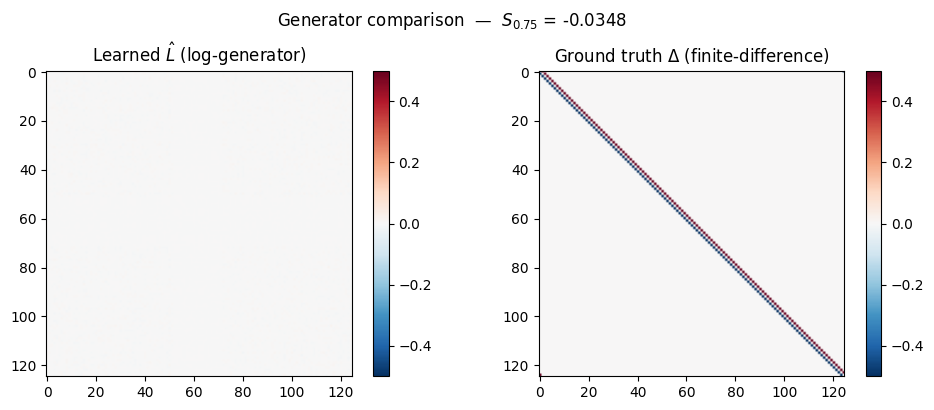

In [8]:
def compute_s_beta(L_learned, L_truth, beta=0.75):
    """Frobenius cosine similarity in the low-frequency Fourier subspace (S_{beta}, paper eq.)."""
    D = L_learned.shape[0]
    k_max = int(np.floor(beta * D))

    # DFT basis — columns are frequency vectors, shape (D, D)
    F = np.fft.fft(np.eye(D), axis=0) / np.sqrt(D)
    F_beta = F[:, :k_max]   # keep k_max lowest-frequency columns

    def project(M):
        return F_beta.conj().T @ M @ F_beta   # (k_max, k_max), complex

    P_hat   = project(L_learned)
    P_truth = project(L_truth)

    num   = np.real(np.trace(P_hat.conj().T @ P_truth))
    denom = np.linalg.norm(P_hat, 'fro') * np.linalg.norm(P_truth, 'fro') + 1e-12
    return num / denom


def finite_difference_generator(D):
    """Skew-symmetric finite-difference generator for 1-D discrete translation on a D-point ring."""
    Delta = np.zeros((D, D))
    for i in range(D):
        Delta[i, (i + 1) % D] =  0.5
        Delta[i, (i - 1) % D] = -0.5
    return Delta


if log_G.shape[0] == 1:
    D = log_G[0].shape[0]

    # For natural (identity) experiments: ground truth is the finite-difference generator.
    # For DST-I or other transforms A: set GROUND_TRUTH to finite_difference_generator(D)
    # and replace log_G[0] with np.linalg.inv(A) @ log_G[0] @ A before calling compute_s_beta.
    GROUND_TRUTH = finite_difference_generator(D)   # set to None to skip

    if GROUND_TRUTH is not None:
        s = compute_s_beta(log_G[0], GROUND_TRUTH, beta=0.75)
        print(f'S_0.75 = {s:.4f}  (paper metric; 1.0 = perfect generator recovery)')

        vmax = max(np.abs(log_G[0]).max(), np.abs(GROUND_TRUTH).max())
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        im0 = axes[0].imshow(log_G[0], cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[0].set_title(r'Learned $\hat{L}$ (log-generator)')
        plt.colorbar(im0, ax=axes[0])
        im1 = axes[1].imshow(GROUND_TRUTH, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
        axes[1].set_title(r'Ground truth $\Delta$ (finite-difference)')
        plt.colorbar(im1, ax=axes[1])
        plt.suptitle(f'Generator comparison  —  $S_{{0.75}}$ = {s:.4f}')
        plt.tight_layout(); plt.show()
    else:
        print('Set GROUND_TRUTH to compute S_0.75.')
else:
    print('S_0.75 shown only for 1-D group (group_dims=1).')

## 9. Head-direction circular correlation $r_{cc}$ (neural_hd experiments)

In [ ]:
from core.circular_evaluation import recover_phase, best_circular_correlation

is_hd = any(f.get('type') == 'neural_hd' for f in exp_specs['data_generator_params']['features'])

if is_hd:
    dg_hd = make_data_generator(seed=seed + 123, **exp_specs['data_generator_params'])
    dg_hd.reset_batch_counter()

    x_hd, params_hd = dg_hd.sample_batch_of_data(return_hidden_params=True)
    true_angle = np.deg2rad(params_hd[:, 0])

    # analyze=True returns (batch, positions, channels): phase lives in the bump
    # position across the group-orbit axis, so FFT must run over positions.
    y_hd, _ = model(tf.constant(x_hd, dtype=tf.float32), training=False, analyze=True)
    recovered = recover_phase(y_hd.numpy(), channel=0)

    r_cc, alignment, candidates = best_circular_correlation(true_angle, recovered)
    print(f'Circular correlation r_cc = {r_cc:.4f}  (alignment: {alignment})')
    print(f'  direct = {candidates["direct"]:.4f} | reflected = {candidates["reflected"]:.4f}')

    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].scatter(true_angle, recovered, s=6, alpha=0.4)
    ax[0].set_xlabel('True head direction (rad)')
    ax[0].set_ylabel('Recovered phase (rad)')
    ax[0].set_title(f'Phase vs head direction  ($r_{{cc}}$ = {r_cc:.3f})')

    order = np.argsort(true_angle)
    ax[1].plot(true_angle[order], np.unwrap(recovered[order]), lw=1)
    ax[1].set_xlabel('True head direction (rad)')
    ax[1].set_ylabel('Recovered phase (unwrapped)')
    ax[1].set_title('Monotonic phase code')
    plt.tight_layout(); plt.show()
else:
    print('Not a neural_hd experiment — skipping circular correlation.')

In [10]:
1+1

2